In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_DIR = Path("../data/raw")

clinical = pd.read_csv(DATA_DIR / "train_clinical_data.csv")
proteins = pd.read_csv(DATA_DIR / "train_proteins.csv")
peptides = pd.read_csv(DATA_DIR / "train_peptides.csv")
supplemental = pd.read_csv(DATA_DIR / "supplemental_clinical_data.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


# Data Audit

This notebook performs an initial exploratory analysis of the AMP Parkinson's Disease Progression dataset. The goal is to understand the structure, dimensions, variables, missingness, and overlap between the clinical, protein, and peptide datasets.

In [3]:
datasets = {
    "Clinical": clinical,
    "Proteins": proteins,
    "Peptides": peptides,
    "Supplemental Clinical": supplemental
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print()

Clinical
Shape: (2615, 8)
Columns: ['visit_id', 'patient_id', 'visit_month', 'updrs_1', 'updrs_2', 'updrs_3', 'updrs_4', 'upd23b_clinical_state_on_medication']

Proteins
Shape: (232741, 5)
Columns: ['visit_id', 'visit_month', 'patient_id', 'UniProt', 'NPX']

Peptides
Shape: (981834, 6)
Columns: ['visit_id', 'visit_month', 'patient_id', 'UniProt', 'Peptide', 'PeptideAbundance']

Supplemental Clinical
Shape: (2223, 8)
Columns: ['visit_id', 'patient_id', 'visit_month', 'updrs_1', 'updrs_2', 'updrs_3', 'updrs_4', 'upd23b_clinical_state_on_medication']



## Dataset Size and Coverage

We examine the number of unique patients, visits, proteins, and peptides available in each dataset.

In [4]:
print("Clinical patients:", clinical["patient_id"].nunique())
print("Clinical visits:", clinical["visit_id"].nunique())

print()

print("Protein patients:", proteins["patient_id"].nunique())
print("Protein visits:", proteins["visit_id"].nunique())
print("Unique proteins:", proteins["UniProt"].nunique())

print()

print("Peptide patients:", peptides["patient_id"].nunique())
print("Peptide visits:", peptides["visit_id"].nunique())
print("Unique peptides:", peptides["Peptide"].nunique())

print()

print("Supplemental patients:", supplemental["patient_id"].nunique())
print("Supplemental visits:", supplemental["visit_id"].nunique())

Clinical patients: 248
Clinical visits: 2615

Protein patients: 248
Protein visits: 1113
Unique proteins: 227

Peptide patients: 248
Peptide visits: 1113
Unique peptides: 968

Supplemental patients: 771
Supplemental visits: 2223


## Dataset Overlap

The protein and peptide measurements are only available for a subset of clinical visits. We examine how many patients and visits overlap across the clinical, protein, peptide, and supplemental datasets.

In [5]:
clinical_visits = set(clinical["visit_id"])
protein_visits = set(proteins["visit_id"])
peptide_visits = set(peptides["visit_id"])
supplemental_visits = set(supplemental["visit_id"])

clinical_patients = set(clinical["patient_id"])
protein_patients = set(proteins["patient_id"])
peptide_patients = set(peptides["patient_id"])
supplemental_patients = set(supplemental["patient_id"])

print("VISIT OVERLAP")
print("-" * 40)
print("Clinical + Protein:", len(clinical_visits & protein_visits))
print("Clinical + Peptide:", len(clinical_visits & peptide_visits))
print("Protein + Peptide:", len(protein_visits & peptide_visits))
print("Clinical + Protein + Peptide:",
      len(clinical_visits & protein_visits & peptide_visits))

print()
print("Supplemental + Main Clinical visits:",
      len(supplemental_visits & clinical_visits))

print()
print("PATIENT OVERLAP")
print("-" * 40)
print("Clinical + Protein patients:",
      len(clinical_patients & protein_patients))
print("Clinical + Peptide patients:",
      len(clinical_patients & peptide_patients))
print("Main Clinical + Supplemental patients:",
      len(clinical_patients & supplemental_patients))

VISIT OVERLAP
----------------------------------------
Clinical + Protein: 1068
Clinical + Peptide: 1068
Protein + Peptide: 1113
Clinical + Protein + Peptide: 1068

Supplemental + Main Clinical visits: 0

PATIENT OVERLAP
----------------------------------------
Clinical + Protein patients: 248
Clinical + Peptide patients: 248
Main Clinical + Supplemental patients: 0


## Missing Data Analysis

We examine missingness in the clinical UPDRS outcomes and medication status to determine which variables are most suitable for analysis and modeling.

In [6]:
clinical_missing = pd.DataFrame({
    "Missing Count": clinical.isna().sum(),
    "Missing Percent": clinical.isna().mean() * 100
})

clinical_missing

,Missing Count,Missing Percent
visit_id,0,0.000000
patient_id,0,0.000000
visit_month,0,0.000000
updrs_1,1,0.038241
updrs_2,2,0.076482
updrs_3,25,0.956023
updrs_4,1038,39.694073
upd23b_clinical_state_on_medication,1327,50.745698


In [7]:
updrs_cols = ["updrs_1", "updrs_2", "updrs_3", "updrs_4"]

for col in updrs_cols:
    print(
        f"{col}: "
        f"{clinical[col].notna().sum()} available, "
        f"{clinical[col].isna().sum()} missing "
        f"({clinical[col].isna().mean() * 100:.1f}% missing)"
    )

updrs_1: 2614 available, 1 missing (0.0% missing)
updrs_2: 2613 available, 2 missing (0.1% missing)
updrs_3: 2590 available, 25 missing (1.0% missing)
updrs_4: 1577 available, 1038 missing (39.7% missing)


### Missingness by Clinical Variable

The UPDRS 1–3 scores are nearly complete, while UPDRS 4 and medication status contain substantially more missing observations.

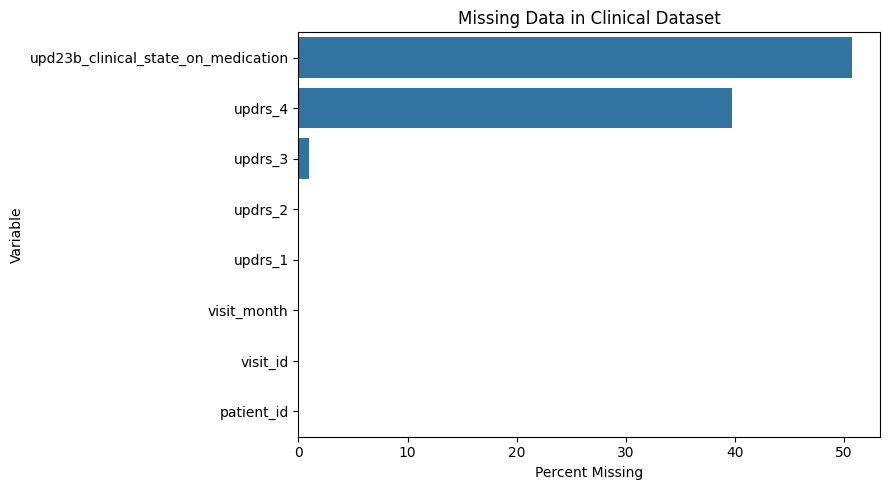

In [8]:
missing_percent = (
    clinical.isna().mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.xlabel("Percent Missing")
plt.ylabel("Variable")
plt.title("Missing Data in Clinical Dataset")

plt.tight_layout()
plt.show()

## Longitudinal Structure

Because the study follows patients over multiple visits, we examine how many visits each patient has and how visits are distributed over time.

In [9]:
visits_per_patient = (
    clinical.groupby("patient_id")["visit_id"]
    .nunique()
)

print("Visits per patient summary:")
print(visits_per_patient.describe())

print()
print("Minimum visit month:", clinical["visit_month"].min())
print("Maximum visit month:", clinical["visit_month"].max())
print("Unique visit months:", sorted(clinical["visit_month"].unique()))

Visits per patient summary:
count    248.000000
mean      10.544355
std        3.596845
min        3.000000
25%        7.000000
50%       10.000000
75%       14.000000
max       17.000000
Name: visit_id, dtype: float64

Minimum visit month: 0
Maximum visit month: 108
Unique visit months: [np.int64(0), np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(18), np.int64(24), np.int64(30), np.int64(36), np.int64(42), np.int64(48), np.int64(54), np.int64(60), np.int64(72), np.int64(84), np.int64(96), np.int64(108)]


### Patient Follow-up and Visit Timing

Patients have repeated clinical assessments over time, but the number and timing of visits vary across patients. We examine the distribution of visits per patient and the number of observations available at each study month.

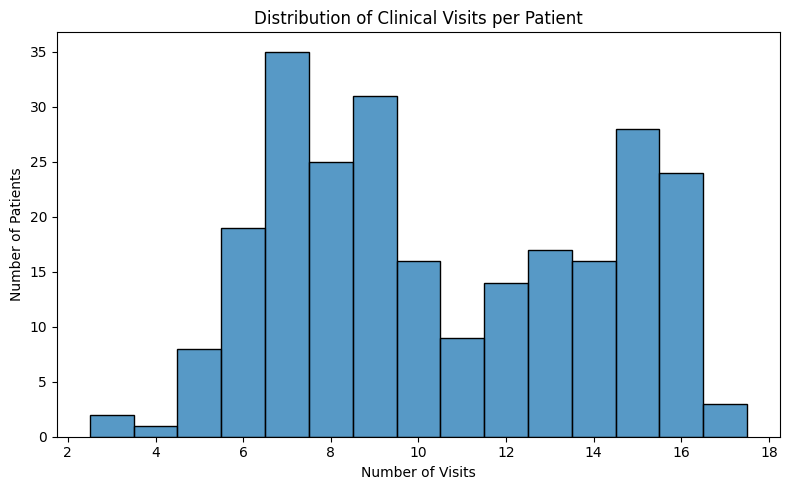

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    visits_per_patient,
    bins=range(
        int(visits_per_patient.min()),
        int(visits_per_patient.max()) + 2
    ),
    discrete=True
)

plt.xlabel("Number of Visits")
plt.ylabel("Number of Patients")
plt.title("Distribution of Clinical Visits per Patient")

plt.tight_layout()
plt.show()

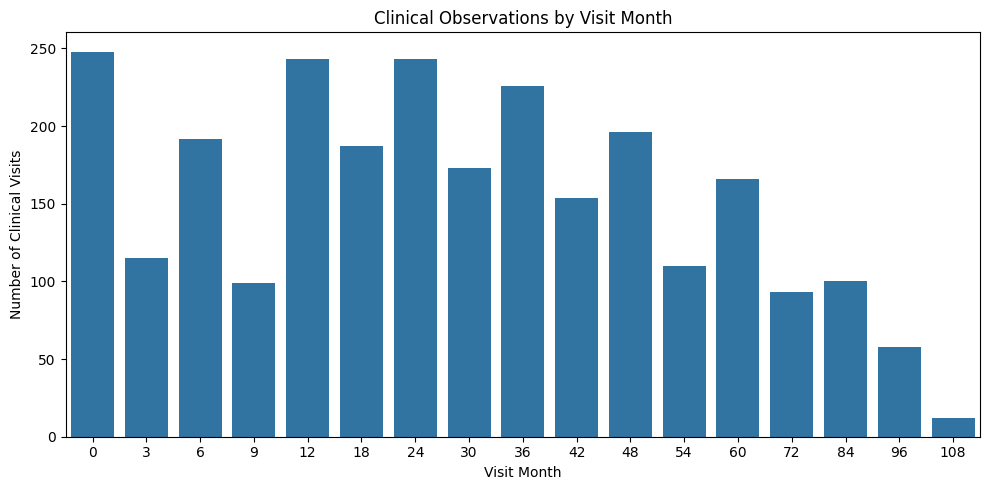

In [11]:
visits_by_month = (
    clinical["visit_month"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=visits_by_month.index,
    y=visits_by_month.values
)

plt.xlabel("Visit Month")
plt.ylabel("Number of Clinical Visits")
plt.title("Clinical Observations by Visit Month")

plt.tight_layout()
plt.show()

## UPDRS Scores Over Time

To examine Parkinson's disease progression, we summarize the average UPDRS scores at each follow-up month. Higher UPDRS scores represent greater symptom severity.

In [12]:
updrs_summary = (
    clinical.groupby("visit_month")[["updrs_1", "updrs_2", "updrs_3", "updrs_4"]]
    .mean()
    .round(2)
)

updrs_summary

,updrs_1,updrs_2,updrs_3,updrs_4
visit_month,,,,
0,5.57,4.44,13.75,2.05
3,5.51,6.63,20.48,0.14
6,7.11,6.96,20.27,2.31
9,6.08,7.20,20.47,0.49
12,6.22,5.32,16.17,1.31
18,7.30,6.87,19.02,1.22
24,6.67,5.66,16.49,1.66
30,8.23,7.65,21.71,1.75
36,7.33,6.23,18.32,1.77


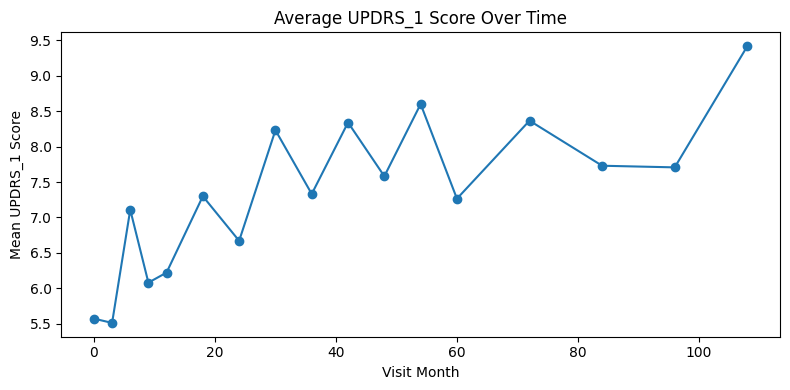

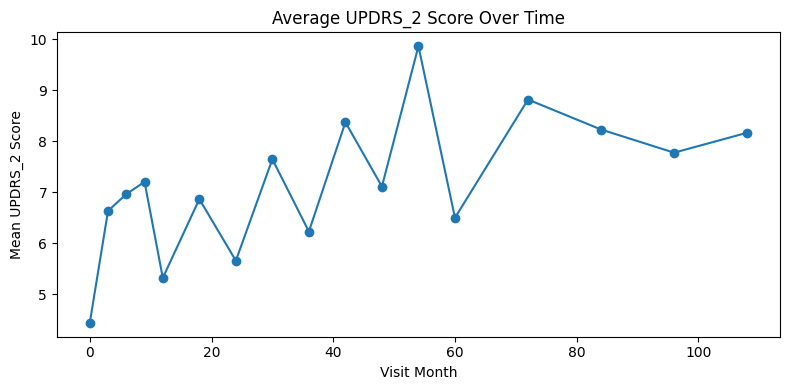

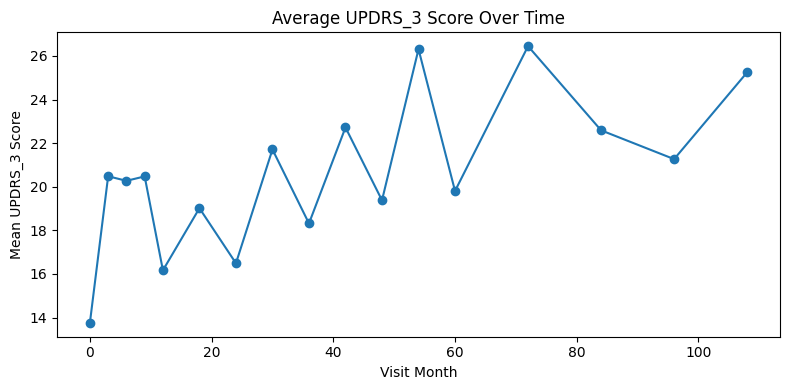

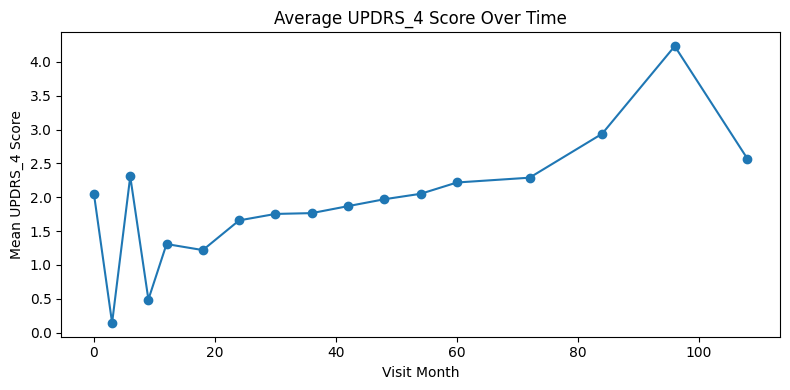

In [13]:
for col in ["updrs_1", "updrs_2", "updrs_3", "updrs_4"]:

    mean_scores = (
        clinical.groupby("visit_month")[col]
        .mean()
    )

    plt.figure(figsize=(8, 4))

    plt.plot(
        mean_scores.index,
        mean_scores.values,
        marker="o"
    )

    plt.xlabel("Visit Month")
    plt.ylabel(f"Mean {col.upper()} Score")
    plt.title(f"Average {col.upper()} Score Over Time")

    plt.tight_layout()
    plt.show()

## Protein and Peptide Data Coverage

We next examine the completeness and structure of the biomarker measurements. Because proteins and peptides are recorded in long format, each visit may contain hundreds of biomarker observations.

In [14]:
print("PROTEIN DATA")
print("-" * 40)

print("Missing NPX values:",
      proteins["NPX"].isna().sum())

print("Percent NPX missing:",
      round(proteins["NPX"].isna().mean() * 100, 2))

proteins_per_visit = (
    proteins.groupby("visit_id")["UniProt"]
    .nunique()
)

print()
print("Unique proteins measured per visit:")
print(proteins_per_visit.describe())


print("\nPEPTIDE DATA")
print("-" * 40)

print("Missing PeptideAbundance values:",
      peptides["PeptideAbundance"].isna().sum())

print("Percent PeptideAbundance missing:",
      round(peptides["PeptideAbundance"].isna().mean() * 100, 2))

peptides_per_visit = (
    peptides.groupby("visit_id")["Peptide"]
    .nunique()
)

print()
print("Unique peptides measured per visit:")
print(peptides_per_visit.describe())

PROTEIN DATA
----------------------------------------
Missing NPX values: 0
Percent NPX missing: 0.0

Unique proteins measured per visit:
count    1113.000000
mean      209.111411
std        12.033458
min        37.000000
25%       206.000000
50%       212.000000
75%       216.000000
max       224.000000
Name: UniProt, dtype: float64

PEPTIDE DATA
----------------------------------------
Missing PeptideAbundance values: 0
Percent PeptideAbundance missing: 0.0

Unique peptides measured per visit:
count    1113.000000
mean      882.150943
std        69.156328
min        94.000000
25%       878.000000
50%       903.000000
75%       917.000000
max       947.000000
Name: Peptide, dtype: float64


### Biomarker Coverage Across Visits

Although the biomarker abundance columns contain no explicit missing values, not every protein or peptide is measured at every visit. Missing biomarker measurements therefore appear as absent rows rather than `NaN` values.

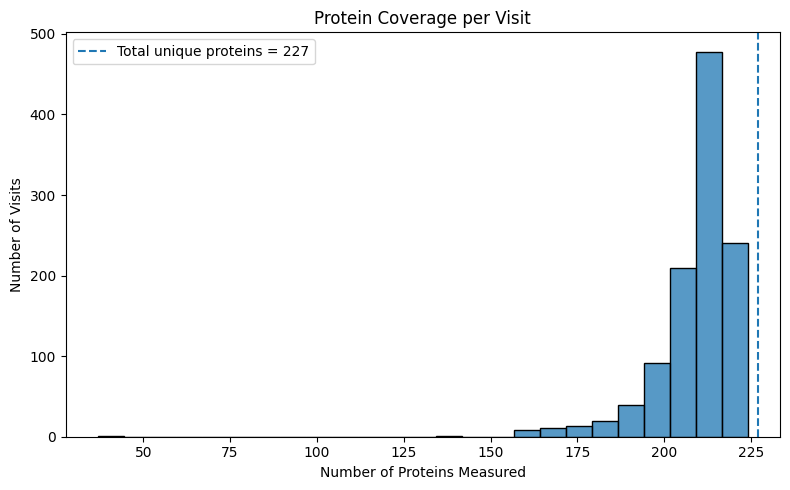

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    proteins_per_visit,
    bins=25
)

plt.axvline(
    proteins["UniProt"].nunique(),
    linestyle="--",
    label="Total unique proteins = 227"
)

plt.xlabel("Number of Proteins Measured")
plt.ylabel("Number of Visits")
plt.title("Protein Coverage per Visit")

plt.legend()
plt.tight_layout()
plt.show()

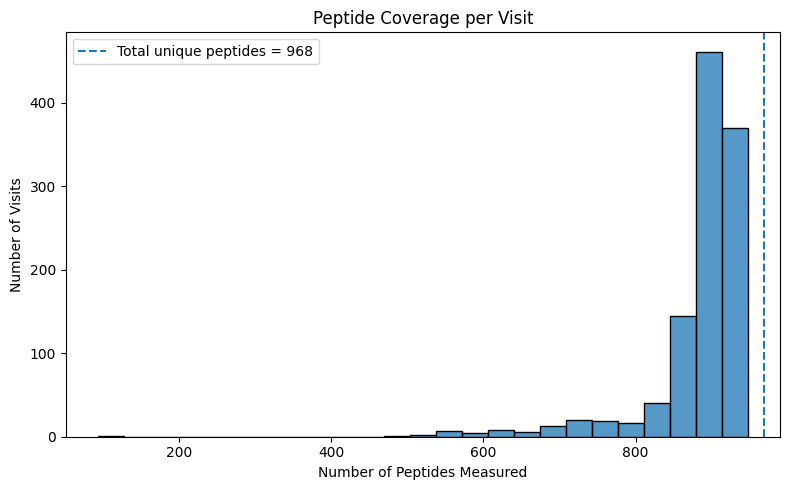

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    peptides_per_visit,
    bins=25
)

plt.axvline(
    peptides["Peptide"].nunique(),
    linestyle="--",
    label="Total unique peptides = 968"
)

plt.xlabel("Number of Peptides Measured")
plt.ylabel("Number of Visits")
plt.title("Peptide Coverage per Visit")

plt.legend()
plt.tight_layout()
plt.show()

## Preparing Protein Data for Modeling

The protein dataset is stored in long format, with one row per protein measurement. We reshape the data so that each visit is represented by one row and each protein becomes a separate feature.

In [17]:
protein_wide = proteins.pivot_table(
    index="visit_id",
    columns="UniProt",
    values="NPX",
    aggfunc="first"
)

print("Protein data in wide format:")
print("Rows (visits):", protein_wide.shape[0])
print("Columns (proteins):", protein_wide.shape[1])

protein_wide.head()

Protein data in wide format:
Rows (visits): 1113
Columns (proteins): 227


UniProt,O00391,O00533,O00584,O14498,O14773,O14791,O15240,O15394,O43505,O60888,...,Q9HDC9,Q9NQ79,Q9NYU2,Q9UBR2,Q9UBX5,Q9UHG2,Q9UKV8,Q9UNU6,Q9Y646,Q9Y6R7
visit_id,,,,,,,,,,,,,,,,,,,,,
10053_0,9104.27,402321.0,NaN,NaN,7150.57,2497.84,83002.9,15113.6,167327.0,129048.0,...,NaN,9469.45,94237.6,NaN,23016.0,177983.0,65900.0,15382.0,NaN,19017.40
10053_12,10464.20,435586.0,NaN,NaN,NaN,NaN,197117.0,15099.1,164268.0,108114.0,...,NaN,14408.40,NaN,NaN,28537.0,171733.0,65668.1,NaN,9295.65,25697.80
10053_18,13235.70,507386.0,7126.96,24525.7,NaN,2372.71,126506.0,16289.6,168107.0,163776.0,...,317477.0,38667.20,111107.0,NaN,37932.6,245188.0,59986.1,10813.3,NaN,29102.70
10138_12,12600.20,494581.0,9165.06,27193.5,22506.10,6015.90,156313.0,54546.4,204013.0,56725.0,...,557904.0,44556.90,155619.0,14647.9,36927.7,229232.0,106564.0,26077.7,21441.80,7642.42
10138_24,12003.20,522138.0,4498.51,17189.8,29112.40,2665.15,151169.0,52338.1,240892.0,85767.1,...,NaN,47836.70,177619.0,17061.1,25510.4,176722.0,59471.4,12639.2,15091.40,6168.55


In [18]:
protein_missing = (
    protein_wide.isna().mean() * 100
).sort_values(ascending=False)

print("Protein missingness summary:")
print(protein_missing.describe())

print()
print("10 proteins with the most missing measurements:")
print(protein_missing.head(10))

Protein missingness summary:
count    227.000000
mean       7.880436
std       12.200201
min        0.000000
25%        0.089847
50%        1.168014
75%       12.443845
max       56.064690
dtype: float64

10 proteins with the most missing measurements:
UniProt
Q99829    56.064690
Q99832    45.552561
Q562R1    44.654088
P01780    41.239892
Q6UX71    40.610961
O75326    37.646002
P06310    37.556155
P19827    37.286613
P36980    36.747529
P02655    36.298293
dtype: float64
